# Wildfire Detection Inference Demo

This notebook loads a trained model and runs inference on a single image.

In [23]:
import torch
import torch.nn.functional as F
from torchvision.transforms import v2
from PIL import Image
import matplotlib.pyplot as plt
import os
import sys

# Import local project files
from models import build_model
import config as C

In [24]:
# Configuration
CHECKPOINT_PATH = "/home/framazan/stat-760/STAT-760-Final/checkpoints/simple_best.pt"  # Change this to your preferred model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [25]:
# Load Checkpoint
ckpt = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=True)
model_name = ckpt.get("model_name", "firenet") # Fallback if not saved in older checkpoints

print(f"Loading model architecture: {model_name}")

# Build model
# Note: pretrained=False because we are loading our own trained weights
model = build_model(model_name, num_classes=len(C.CLASSES), pretrained=False)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)
model.eval()
print(f"Model loaded successfully. Validation Accuracy was: {ckpt.get('val_acc', 0.0):.4f}")

Loading model architecture: simple
Model loaded successfully. Validation Accuracy was: 0.9252


In [26]:
# Define Image Preprocessing
transform = v2.Compose([
    v2.Resize((C.IMAGE_SIZE, C.IMAGE_SIZE)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=C.MEAN, std=C.STD)
])

def predict_image(img_path):
    # Load image
    img = Image.open(img_path).convert("RGB")
    
    # Preprocess and add batch dimension
    tensor = transform(img).unsqueeze(0).to(device)
    
    # Inference
    with torch.no_grad():
        logits = model(tensor)
        probs = F.softmax(logits, dim=1)[0]
        
    pred_idx = torch.argmax(probs).item()
    pred_class = C.CLASSES[pred_idx]
    confidence = probs[pred_idx].item()
    
    # Display
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    
    # Color formatting
    color = 'red' if pred_class == 'positive' else 'green'
    title = f"Prediction: {pred_class.upper()} ({confidence*100:.1f}%)"
    plt.title(title, color=color, fontsize=14, fontweight='bold')
    plt.show()
    
    print(f"Probabilities:\nNegative: {probs[0]:.4f}\nPositive: {probs[1]:.4f}")
    return pred_class, probs.tolist()

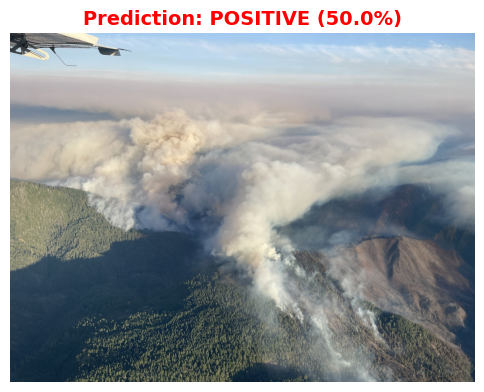

Probabilities:
Negative: 0.5000
Positive: 0.5000


In [ ]:
# Run prediction
IMAGE_PATH = "/home/framazan/stat-760/STAT-760-Final/test/301.jpg" # Change this to test different images
if os.path.exists(IMAGE_PATH):
    predict_image(IMAGE_PATH)
else:
    print(f"Could not find image at {IMAGE_PATH}. Please provide a valid path.")